<a href="https://colab.research.google.com/github/cyanm002-maker/Deep_learning_project/blob/main/RNN_amazon_sentiment.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

1.Importing necessary Libraries


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import re
import seaborn as sns
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
import tensorflow as tf
from tensorflow.keras.layers import SimpleRNN, LSTM, Dense, Dropout, Embedding,  BatchNormalization
from tensorflow.keras.models import Sequential
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.utils import pad_sequences

import warnings
warnings.filterwarnings('ignore')

2.Loading dataset


In [ ]:
import pandas as pd
data = pd.read_csv('/content/drive/MyDrive/Amazon-Product-Review-Sentiment-Analysis-using-RNN-Dataset.csv')

print(data.shape)

print(data.info()) # This is written to get the information about the dataset like median etc

(25000, 2)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25000 entries, 0 to 24999
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   Review     24999 non-null  object
 1   Sentiment  25000 non-null  int64 
dtypes: int64(1), object(1)
memory usage: 390.8+ KB
None


3 Exploratory Data Analysis

In [ ]:
print("Null Vals:",data.isna().sum()) # This is written for getting the NULL values

data = data.dropna()

print("Null values after dropping:",data.isna().sum())

Null Vals: Review       1
Sentiment    0
dtype: int64
Null values after dropping: Review       0
Sentiment    0
dtype: int64


In [ ]:
data['Sentiment'].value_counts()

,count
Sentiment,
1,5000
2,5000
3,5000
4,5000
5,4999


4. Text cleaning

In [ ]:
nltk.download('stopwords')
stop_words = set(stopwords.words('english'))

nltk.download('punkt')
nltk.download('punkt_tab')

# Review text cleaning
def clean_reviews(text):

  # removing the html bracket
  regex = re.compile('<.*?>')
  text = re.sub(regex,'',text)

  pattern = re.compile('[^a-zA-z0-9\s]')
  text = re.sub(pattern,'',text)

  text = text.lower()
  # tokenize the word
  text = word_tokenize(text)

  text=[word for word in text if not word in stop_words]

  return text

data['Review'] = data['Review'].apply(clean_reviews)

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


4. Tokenization & Text Encoding

In [ ]:
tokenizer = Tokenizer()

# converting all the reviews to list to pass it as a parameter to fit_on_texts
reviews_to_list = data['Review'].tolist()
tokenizer.fit_on_texts(reviews_to_list)

# Generating text sequences
text_sequences = tokenizer.texts_to_sequences(reviews_to_list)

# setting maximum words we want in an example
max_words = 500

# Padding sequences
# - Before converting to a NumPy array, pad the sequences to ensure they all have the same length.
padded_sequences = pad_sequences(text_sequences, maxlen=max_words) # Use the same max_words value

text_sequences = np.array(padded_sequences)

# one hot encoding
data = pd.get_dummies(data, columns = ['Sentiment'])


# Generatin our X (input) to the model
# using pad_sequences and y (output)
X = pad_sequences(text_sequences, maxlen = max_words)
y = data[['Sentiment_1', 'Sentiment_2', 'Sentiment_3', 'Sentiment_4',
    'Sentiment_5']]
print(X.shape, y.shape)



(24999, 500) (24999, 5)


5. Train-test split


In [ ]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)

print(X_train.shape, X_test.shape, y_train.shape, y_test.shape)

(18749, 500) (6250, 500) (18749, 5) (6250, 5)


Model building

In [ ]:
# Creating a RNN model
rnn = Sequential(name="Simple_RNN")
rnn.add(Embedding(len(tokenizer.word_index)+1,
                        max_words,
                        input_length=max_words))

rnn.add(SimpleRNN(128,activation='relu',return_sequences=True))

rnn.add(SimpleRNN(64,activation='relu',return_sequences=False))

rnn.add(Dense(5, activation='softmax'))

# printing model summary
print(rnn.summary())

rnn.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

Model: "Simple_RNN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn (SimpleRNN)          │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn_1 (SimpleRNN)        │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

None


In [ ]:
rnn.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

In [ ]:
history = rnn.fit(X_train, y_train, epochs=5, batch_size=64, validation_split=0.2)

Epoch 1/5
235/235 ━━━━━━━━━━━━━━━━━━━━ 31s 108ms/step - accuracy: 0.3280 - loss: 1.4747 - val_accuracy: 0.3933 - val_loss: 1.3307
Epoch 2/5
235/235 ━━━━━━━━━━━━━━━━━━━━ 22s 95ms/step - accuracy: 0.5255 - loss: 1.1272 - val_accuracy: 0.4419 - val_loss: 1.2840
Epoch 3/5
235/235 ━━━━━━━━━━━━━━━━━━━━ 42s 98ms/step - accuracy: 0.6972 - loss: 0.7753 - val_accuracy: 0.4064 - val_loss: 1.5078
Epoch 4/5
235/235 ━━━━━━━━━━━━━━━━━━━━ 40s 95ms/step - accuracy: 0.8305 - loss: 0.4575 - val_accuracy: 0.4075 - val_loss: 1.7701
Epoch 5/5
235/235 ━━━━━━━━━━━━━━━━━━━━ 22s 94ms/step - accuracy: 0.9111 - loss: 0.2460 - val_accuracy: 0.3960 - val_loss: 2.4042


In [ ]:
print("Simle_RNN score --->:",rnn.evaluate(X_test, y_test,verbose=1))

196/196 ━━━━━━━━━━━━━━━━━━━━ 6s 25ms/step - accuracy: 0.3810 - loss: 2.4815
Simle_RNN score --->: [2.481463670730591, 0.38095998764038086]


LSTM

Text(0, 0.5, 'Accuracy')

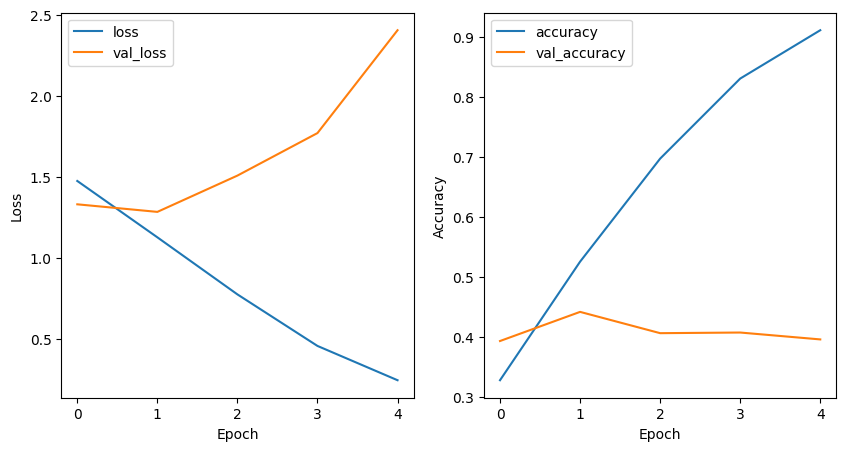

In [ ]:
# Plotting the history
metrics = history.history
plt.figure(figsize=(10, 5))

# Plotting training and validation loss
plt.subplot(1, 2, 1)
plt.plot(history.epoch, metrics['loss'], metrics['val_loss'])
plt.legend(['loss', 'val_loss'])
plt.xlabel('Epoch')
plt.ylabel('Loss')

# Plotting training and validation accuracy
plt.subplot(1, 2, 2)
plt.plot(history.epoch, metrics['accuracy'],
         metrics['val_accuracy'])
plt.legend(['accuracy', 'val_accuracy'])
plt.xlabel('Epoch')
plt.ylabel('Accuracy')

196/196 ━━━━━━━━━━━━━━━━━━━━ 10s 17ms/step


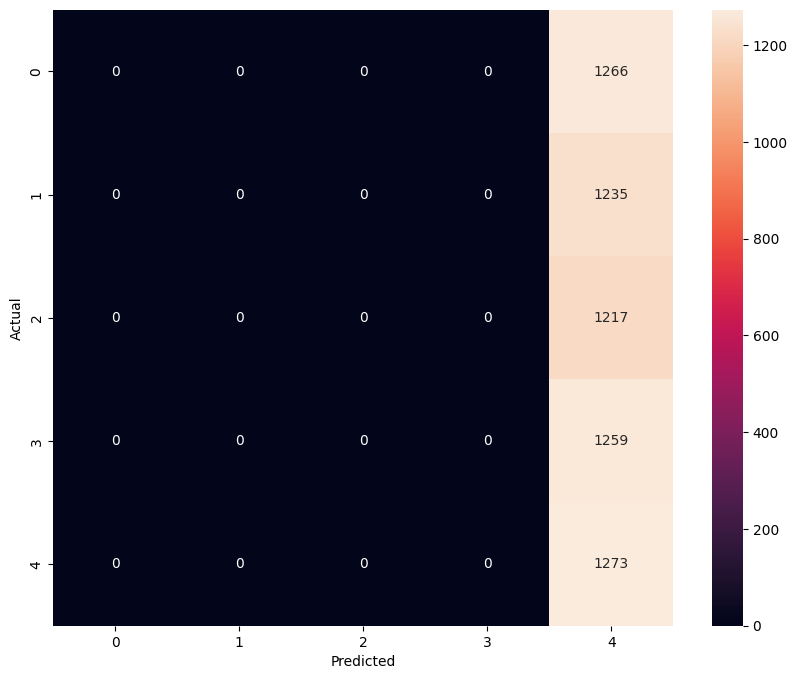

In [ ]:
# converting y_test tht was one hot encoded to one column fo rconfusion matrix
y_true = np.argmax(y_test.values, axis=1)
y_true.shape

# Confusion matrix
y_pred = np.argmax(model.predict(X_test), axis=1)
cm = tf.math.confusion_matrix(y_true, y_pred)

# Plotting the confusion matrix
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='g')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()


In [ ]:
from sklearn.metrics import classification_report
report = classification_report(y_true, y_pred)
print(report)

              precision    recall  f1-score   support

           0       0.00      0.00      0.00      1266
           1       0.00      0.00      0.00      1235
           2       0.00      0.00      0.00      1217
           3       0.00      0.00      0.00      1259
           4       0.20      1.00      0.34      1273

    accuracy                           0.20      6250
   macro avg       0.04      0.20      0.07      6250
weighted avg       0.04      0.20      0.07      6250



In [ ]:
def predict_review_rating(text):
  text_sequences_test = np.array(tokenizer.texts_to_sequences([text]))
  testing = pad_sequences(text_sequences_test, maxlen = max_words)
  y_pred_test = np.argmax(rnn.predict(testing), axis=1)
  return y_pred_test[0]+1

# Testing

a = input("Enter the input")
rating1 = predict_review_rating(a)
print("The rating according to the review is: ", rating1)



Enter the inputworst
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step
The rating according to the review is:  1
